
# Notebook Membuat Model AI Pendeteksi Ekspresi Wajah Manusia



In [64]:
!pip install -q ultralytics gdown pandas scikit-learn optuna matplotlib seaborn pillow ipywidgets


## 1. Import libraries


In [65]:
import os
import shutil
import glob
import random
import yaml
import cv2
import torch
import pandas as pd
import optuna
import io
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from IPython.display import Image as IPyImage, display, clear_output


## 2. Download dan ekstrak Dataset


In [66]:
file_id = '1qKM6fbgsctTZ1uQZu2QNmWd9FHoQ7Mxo'
zip_path = 'dataset.zip'

if not os.path.exists(zip_path):
    !gdown https://drive.google.com/uc?id={file_id} -O {zip_path}

if not os.path.exists('dataset_extracted'):
    !unzip -q {zip_path} -d dataset_extracted


## 3. Persiapkan Dataset for YOLOv8


In [67]:
target_classes = ['anger', 'happy', 'sad']
class_mapping = {name: i for i, name in enumerate(target_classes)}

splits = ['train', 'valid', 'test']
base_dir = 'dataset_extracted' 
extracted_folders = os.listdir(base_dir)
if 'train' not in extracted_folders:
    for f in extracted_folders:
        if os.path.isdir(os.path.join(base_dir, f)) and 'train' in os.listdir(os.path.join(base_dir, f)):
            base_dir = os.path.join(base_dir, f)
            break

output_dir = 'yolo_dataset'
os.makedirs(output_dir, exist_ok=True)

for split in splits:
    os.makedirs(os.path.join(output_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels', split), exist_ok=True)
    
    csv_path = os.path.join(base_dir, split, '_annotations.csv')
    if not os.path.exists(csv_path):
        continue
        
    df = pd.read_csv(csv_path)
    df = df[df['class'].isin(target_classes)]
    
    grouped = df.groupby('filename')
    
    for filename, group in tqdm(grouped, desc=f"Processing {split}"):
        src_img_path = os.path.join(base_dir, split, filename)
        dst_img_path = os.path.join(output_dir, 'images', split, filename)
        
        if not os.path.exists(src_img_path):
            src_img_path = os.path.join(base_dir, split, 'images', filename)
            
        if not os.path.exists(src_img_path):
            continue
            
        img = cv2.imread(src_img_path)
        if img is None:
            continue
        h_img, w_img, _ = img.shape
        
        shutil.copy(src_img_path, dst_img_path)
        
        label_filename = filename.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(output_dir, 'labels', split, label_filename)
        
        with open(label_path, 'w') as f:
            for _, row in group.iterrows():
                cls_id = class_mapping[row['class']]
                xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
                w_box = (xmax - xmin) / w_img
                h_box = (ymax - ymin) / h_img
                cx = (xmin + (xmax - xmin) / 2) / w_img
                cy = (ymin + (ymax - ymin) / 2) / h_img
                f.write(f"{cls_id} {cx:.6f} {cy:.6f} {w_box:.6f} {h_box:.6f}\n")

Processing test: 100%|██████████| 349/349 [00:00<00:00, 377.29it/s]



## 4. Membuat Data yaml untuk YOLOv8 agar mengetahui lokasi dataset dan class yang digunakan


In [68]:
data_yaml = {
    'train': '../yolo_dataset/images/train',
    'val': '../yolo_dataset/images/valid',
    'test': '../yolo_dataset/images/test',
    'nc': len(target_classes),
    'names': target_classes
}

with open('yolo_dataset/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)


## 5. Visualisasi Dataset


Menampilkan sampel dataset latih (Training Set):


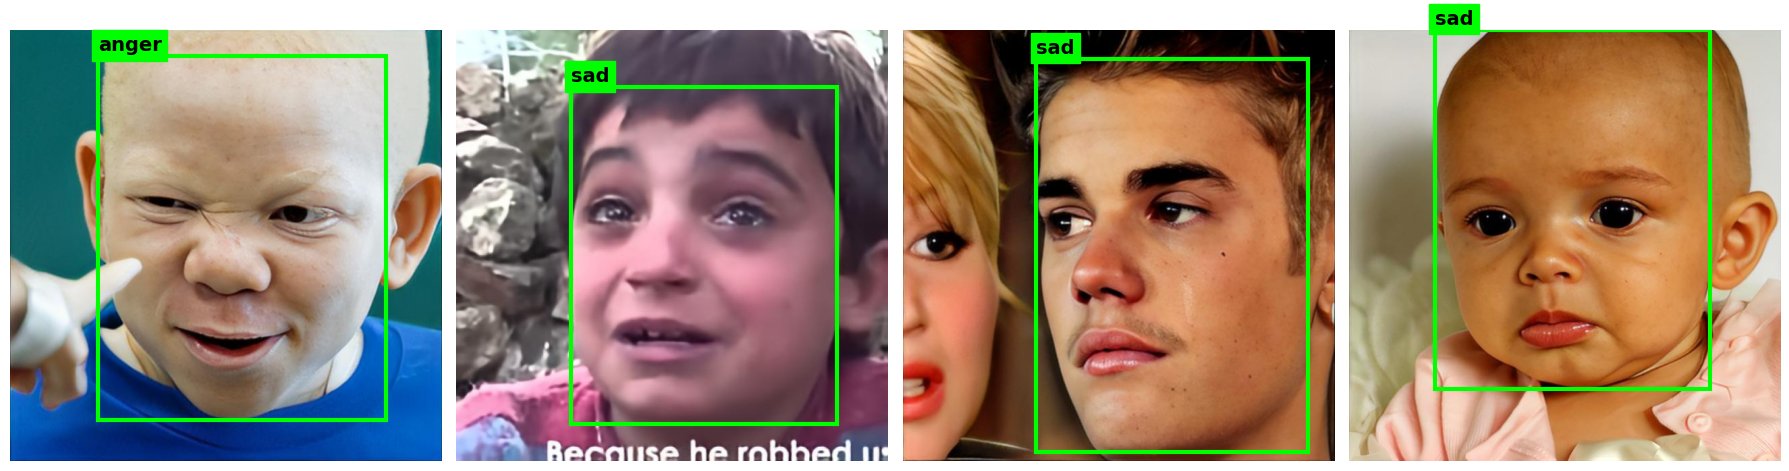

In [69]:
def plot_sample_images(image_dir, label_dir, class_names, num_samples=4):
    images = glob.glob(os.path.join(image_dir, '*.jpg'))
    if not images:
        print("No images found for visualization.")
        return
        
    samples = random.sample(images, min(num_samples, len(images)))
    
    fig, axes = plt.subplots(1, len(samples), figsize=(18, 6))
    if num_samples == 1:
        axes = [axes]
        
    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        
        basename = os.path.basename(img_path)
        label_path = os.path.join(label_dir, basename.replace('.jpg', '.txt'))
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id, cx, cy, w, h = map(float, parts)
                        
                        img_w, img_h = img.size
                        abs_w = w * img_w
                        abs_h = h * img_h
                        abs_x = (cx * img_w) - (abs_w / 2)
                        abs_y = (cy * img_h) - (abs_h / 2)
                        
                        rect = patches.Rectangle((abs_x, abs_y), abs_w, abs_h, linewidth=3, edgecolor='#00ff00', facecolor='none')
                        ax.add_patch(rect)
                        
                        class_name = class_names[int(cls_id)]
                        ax.text(abs_x, abs_y - 8, class_name, color='black', fontsize=14, fontweight='bold', backgroundcolor='#00ff00')

    plt.tight_layout()
    plt.show()

print("Menampilkan sampel dataset latih (Training Set):")
plot_sample_images('yolo_dataset/images/train', 'yolo_dataset/labels/train', target_classes, num_samples=4)


## 6. Fine Tuning dengan Optuna


In [70]:
def objective(trial):
    lr0 = trial.suggest_float('lr0', 1e-4, 1e-2, log=True)
    momentum = trial.suggest_float('momentum', 0.6, 0.98)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    
    model = YOLO('yolov8s.pt')
    
    results = model.train(
        data='yolo_dataset/data.yaml',
        epochs=10, 
        imgsz=640,
        batch=16,
        lr0=lr0,
        momentum=momentum,
        weight_decay=weight_decay,
        dropout=dropout,
        project='optuna_tuning',
        name=f'trial_{trial.number}',
        verbose=False
    )
    
    torch.cuda.empty_cache()
    return results.box.map

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)
print("Best Hyperparameters:", study.best_params)

[I 2026-08-04 10:59:05,659] A new study created in memory with name: no-name-7a154357-6682-4b41-bc1e-4cda763aeefb


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.10718973277995679, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002060085857718421, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.8047062479637319, mosaic=1.0, multi_scale=0.0,

[I 2026-08-04 11:06:53,273] Trial 0 finished with value: 0.787976049412037 and parameters: {'lr0': 0.002060085857718421, 'momentum': 0.8047062479637319, 'weight_decay': 1.3984179759388808e-05, 'dropout': 0.10718973277995679}. Best is trial 0 with value: 0.787976049412037.


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.20375012826115224, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003267123851033159, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.6559297500940497, mosaic=1.0, multi_scale=0.0

[I 2026-08-04 11:14:40,791] Trial 1 finished with value: 0.8008248127603589 and parameters: {'lr0': 0.0003267123851033159, 'momentum': 0.6559297500940497, 'weight_decay': 9.60531580594626e-05, 'dropout': 0.20375012826115224}. Best is trial 1 with value: 0.8008248127603589.


...

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.1749378187546323, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0026024550754929206, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.8536298473619064, mosaic=1.0, multi_scale=0.0,

[I 2026-08-04 11:30:17,635] Trial 3 finished with value: 0.7969506569429293 and parameters: {'lr0': 0.0026024550754929206, 'momentum': 0.8536298473619064, 'weight_decay': 4.3549296730292084e-05, 'dropout': 0.1749378187546323}. Best is trial 2 with value: 0.8032601093280629.


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.12714845013165588, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00023291541522487582, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.7827702696640184, mosaic=1.0, multi_scale=0.

[I 2026-08-04 11:38:06,111] Trial 4 finished with value: 0.7974826716041654 and parameters: {'lr0': 0.00023291541522487582, 'momentum': 0.7827702696640184, 'weight_decay': 0.00023338552408612586, 'dropout': 0.12714845013165588}. Best is trial 2 with value: 0.8032601093280629.


Best Hyperparameters: {'lr0': 0.008090801087655029, 'momentum': 0.6236903354791579, 'weight_decay': 8.547047882546808e-05, 'dropout': 0.11205804627775892}



## 7. Training model dengan hasil Optuna


In [74]:
best_params = study.best_params

model = YOLO('yolov8s.pt')

results = model.train(
    data='yolo_dataset/data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    patience=25, 
    augment=True,
    project='emotion_classification',
    name='final_model',
    exist_ok=True, 
    **best_params 
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.11205804627775892, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.008090801087655029, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.6236903354791579, mosaic=1.0, multi_scale=0.0, n


## 8. Visualisasi Hasil Training


Menampilkan Kurva Training dari: /kaggle/working/runs/detect/emotion_classification/final_model/results.png


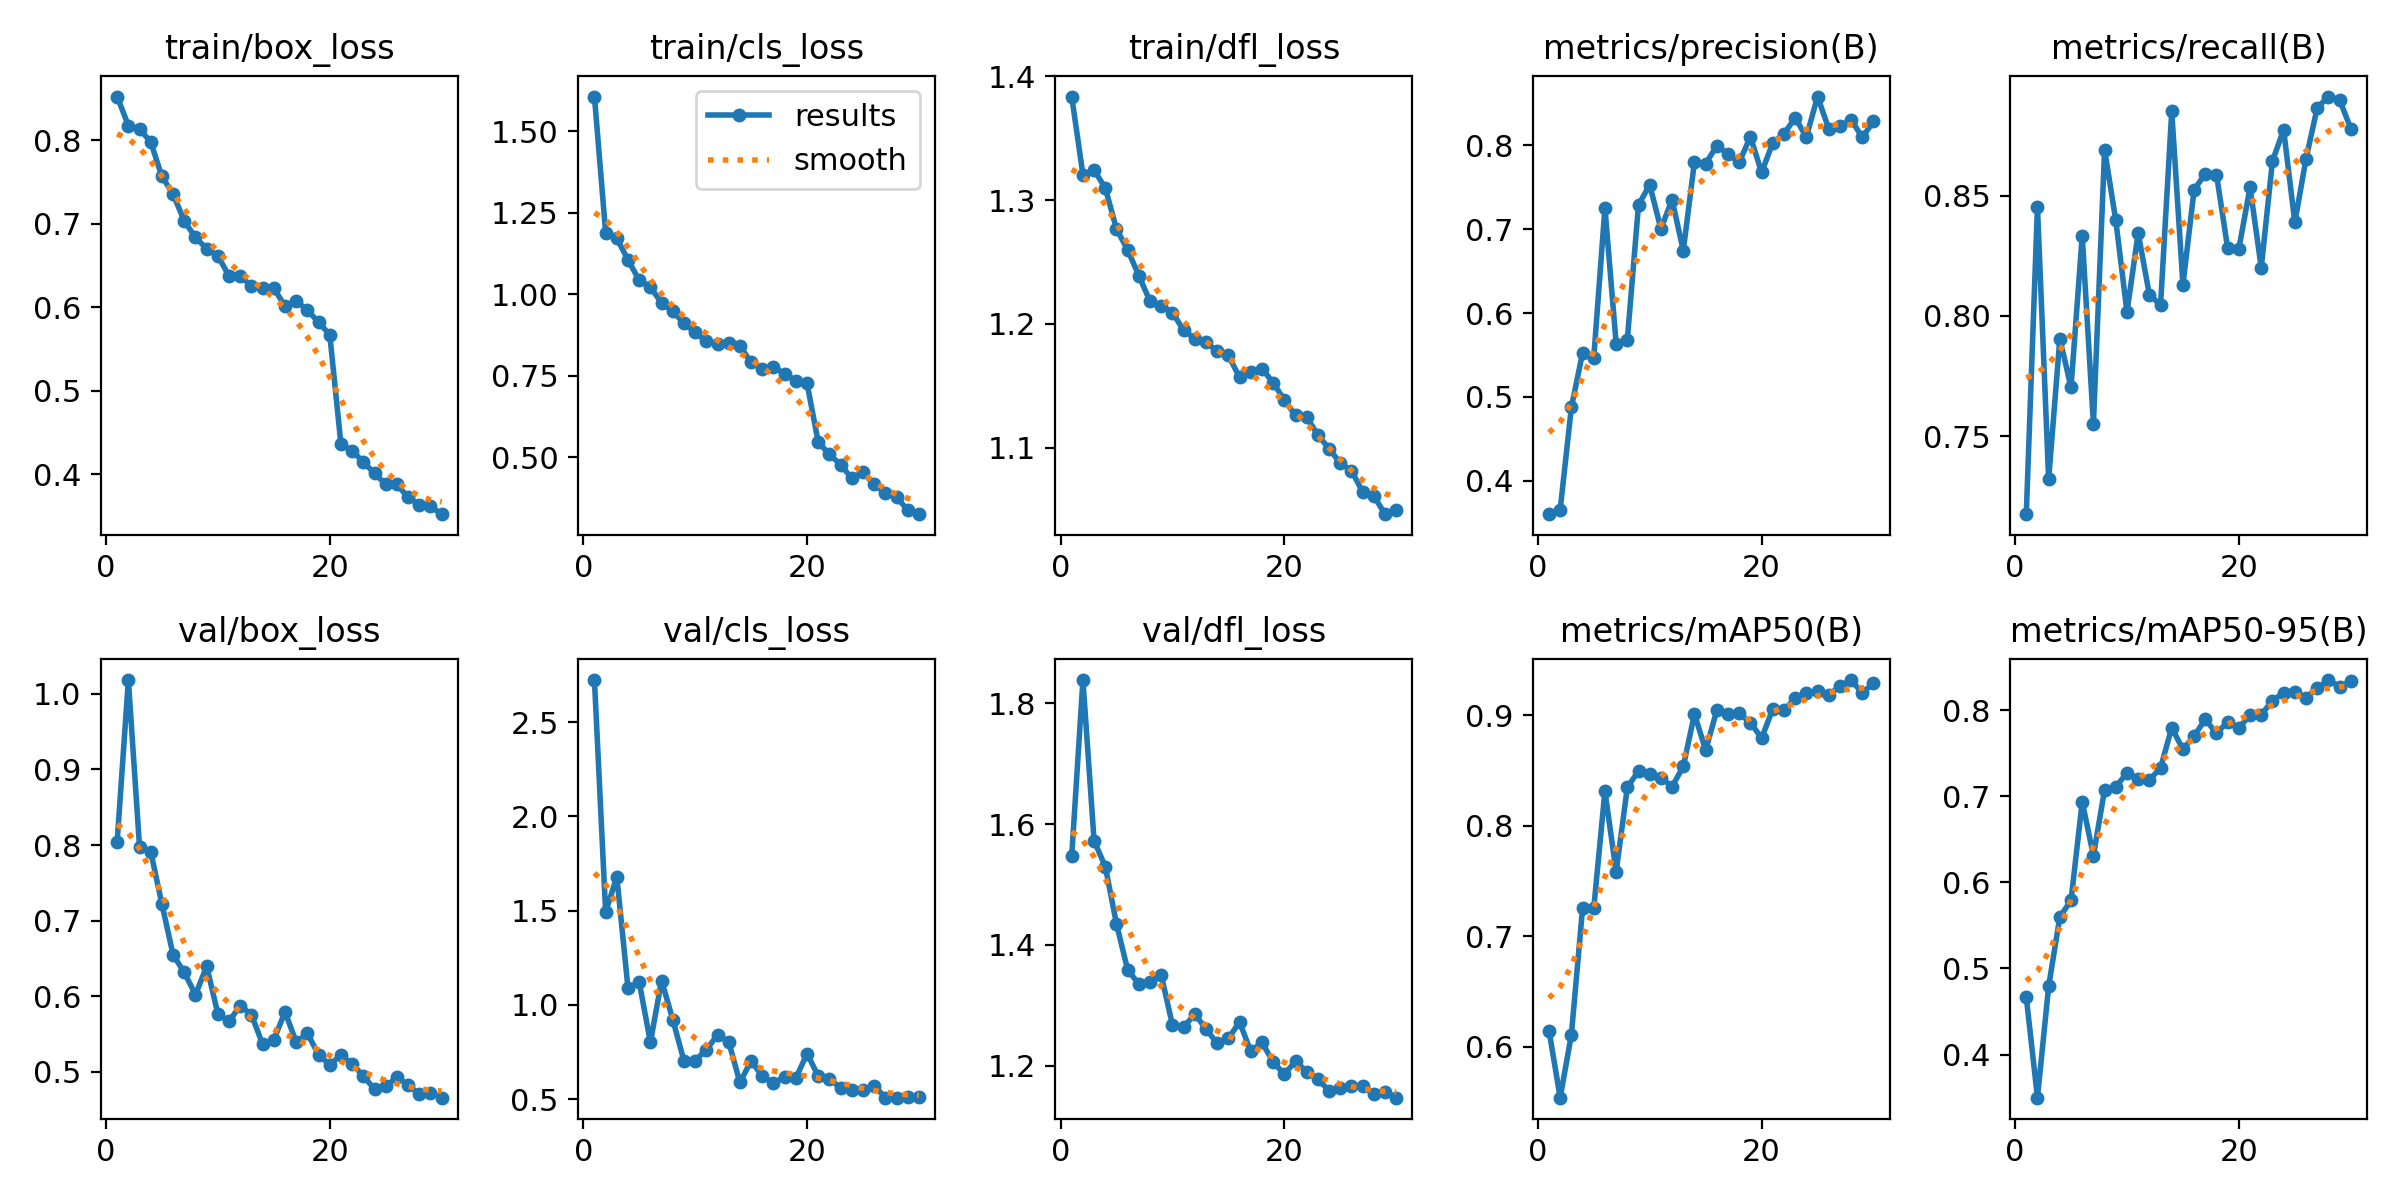

In [86]:
run_dirs = glob.glob('/kaggle/working/runs/detect/emotion_classification/*')
if run_dirs:
    latest_dir = max(run_dirs, key=os.path.getmtime)
    results_plot_path = os.path.join(latest_dir, 'results.png')

    if os.path.exists(results_plot_path):
        print(f"Menampilkan Kurva Training dari: {results_plot_path}")
        display(IPyImage(filename=results_plot_path))
    else:
        print(f"File plot tidak ditemukan di {results_plot_path}. Apakah proses training final sudah selesai?")
else:
    print("Folder training emotion_classification belum dibuat.")


## 9. Validaasi dengan Test-Time Augmentation (TTA)


In [93]:
run_dirs = glob.glob('/kaggle/working/runs/detect/emotion_classification/*')
if run_dirs:
    latest_dir = max(run_dirs, key=os.path.getmtime)
    best_model_path = os.path.join(latest_dir, 'weights', 'best.pt')

    if os.path.exists(best_model_path):
        print(f"Menggunakan model dari: {best_model_path}")
        best_model = YOLO(best_model_path)
        metrics = best_model.val(data='yolo_dataset/data.yaml', split='test', augment=True)
        print(f"Test mAP50-95: {metrics.box.map:.4f}")
    else:
        print(f"Model weights tidak ditemukan di {best_model_path}. Apakah proses training final 50 epoch sudah selesai?")
else:
    print("Folder training tidak ditemukan. Harap jalankan cell 'Train Final Model' terlebih dahulu.")

Menggunakan model dari: /kaggle/working/runs/detect/emotion_classification/final_model/weights/best.pt
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 988.6±253.5 MB/s, size: 44.5 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/test... 349 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 1.2Kit/s 0.3s<0.2s
val: New cache created: /kaggle/working/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.1it/s 10.6s0.4s
                   all        349        360      0.886      0.847      0.937      0.834
                 anger        109        109      0.856      0.872      0.931      0.804
                 happy        114        123      0.975      0.854      0.969      0.874
                   sad        127    


## 10. Clasification Report dan Confusion Matrix


Predicting: 100%|██████████| 349/349 [00:04<00:00, 71.52it/s]



--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.81      0.83      0.82       109
       happy       0.89      0.92      0.90       113
         sad       0.82      0.77      0.79       127

    accuracy                           0.84       349
   macro avg       0.84      0.84      0.84       349
weighted avg       0.84      0.84      0.84       349



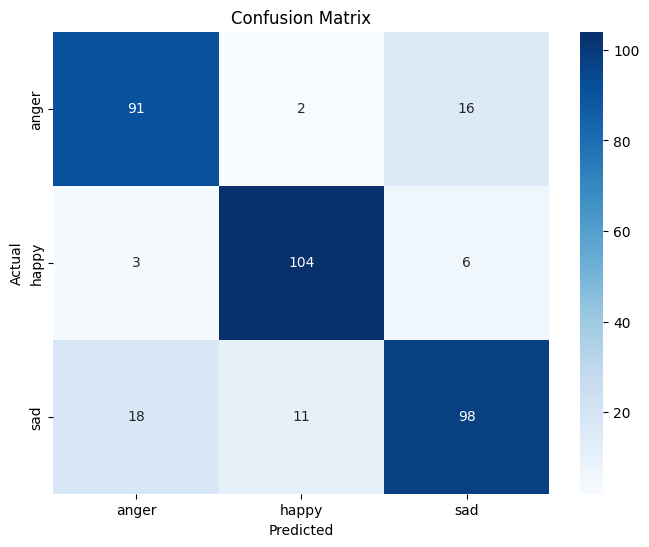

In [96]:
if 'best_model' not in locals() and 'best_model' not in globals():
    print("Error: best_model belum dimuat. Tolong jalankan cell Validasi (TTA) di atas terlebih dahulu.")
else:
    test_images = glob.glob('yolo_dataset/images/test/*.jpg')
    test_labels_dir = 'yolo_dataset/labels/test'
    
    y_true = []
    y_pred = []
    
    for img_path in tqdm(test_images, desc="Predicting"):
        filename = os.path.basename(img_path)
        label_filename = filename.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(test_labels_dir, label_filename)
        
        if not os.path.exists(label_path):
            continue
        with open(label_path, 'r') as f:
            lines = f.readlines()
            if len(lines) == 0:
                continue
            gt_class = int(lines[0].split()[0])
            
        results_pred = best_model.predict(img_path, conf=0.25, verbose=False)
        if len(results_pred) > 0 and len(results_pred[0].boxes) > 0:
            boxes = results_pred[0].boxes
            best_box = boxes[boxes.conf.argmax()]
            pred_class = int(best_box.cls.item())
        else:
            pred_class = -1
            
        y_true.append(gt_class)
        y_pred.append(pred_class)
    
    target_names = target_classes + ['None'] if -1 in y_pred else target_classes
    labels_idx = list(range(len(target_classes)))
    if -1 in y_pred: labels_idx.append(-1)
    
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, labels=labels_idx, target_names=target_names))
    
    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


## 11. Save Model


In [95]:
run_dirs = glob.glob('/kaggle/working/runs/detect/emotion_classification/*')
if run_dirs:
    latest_dir = max(run_dirs, key=os.path.getmtime)
    final_weights = os.path.join(latest_dir, 'weights', 'best.pt')
    export_path_pt = 'best_emotion_model.pt'

    if os.path.exists(final_weights):
        shutil.copy(final_weights, export_path_pt)
        print(f"Model tersimpan ke: {export_path_pt}")
        
        # Export ke format ONNX
        if 'best_model' in locals() or 'best_model' in globals():
            print("Mengekspor model ke format ONNX...")
            best_model.export(format='onnx')
            onnx_path = final_weights.replace('.pt', '.onnx')
            if os.path.exists(onnx_path):
                shutil.copy(onnx_path, 'best_emotion_model.onnx')
                print("Model berhasil diekspor ke: best_emotion_model.onnx")
    else:
        print(f"File weights tidak ditemukan di {final_weights}.")
else:
    print("Folder training tidak ditemukan.")

Model tersimpan ke: best_emotion_model.pt
Mengekspor model ke format ONNX...
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/emotion_classification/final_model/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 355ms
Prepared 2 packages in 312ms
Installed 2 packages in 13ms
 + onnxruntime==1.28.0
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.95...
ONNX:


## 12. Upload Gambar untuk testing model


In [98]:
print("Silakan upload gambar untuk menguji model:")
upload_btn = widgets.FileUpload(
    accept='image/*', 
    multiple=False 
)
out = widgets.Output()

def on_upload_change(change):
    with out:
        clear_output()
        if not upload_btn.value:
            return
            
        uploaded_file = upload_btn.value
        
        if isinstance(uploaded_file, dict):
            filename = list(uploaded_file.keys())[0]
            content = uploaded_file[filename]['content']
        else:
            content = uploaded_file[0]['content']
            
        img = Image.open(io.BytesIO(content)).convert('RGB')
        temp_path = "temp_upload.jpg"
        img.save(temp_path)
        
        print("Mendeteksi wajah dan emosi...")
        try:
            if 'best_model' not in locals() and 'best_model' not in globals():
                print("Error: best_model belum siap. Silakan jalankan cell validasi terlebih dahulu.")
                return
                
            results_infer = best_model.predict(temp_path, conf=0.25)
            res_img = results_infer[0].plot()
            res_img_rgb = cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(8, 8))
            plt.imshow(res_img_rgb)
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Terjadi error saat prediksi: {e}")

upload_btn.observe(on_upload_change, names='value')
display(upload_btn, out)

Silakan upload gambar untuk menguji model:


FileUpload(value=(), accept='image/*', description='Upload')

Output()